<a href="https://colab.research.google.com/github/Bijanshu-Yadav/Disaster-Damage-Detection/blob/main/Damage%20Detection%20System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
pip install opencv-python numpy matplotlib


Damage: 97.72%
Label: Destroyed


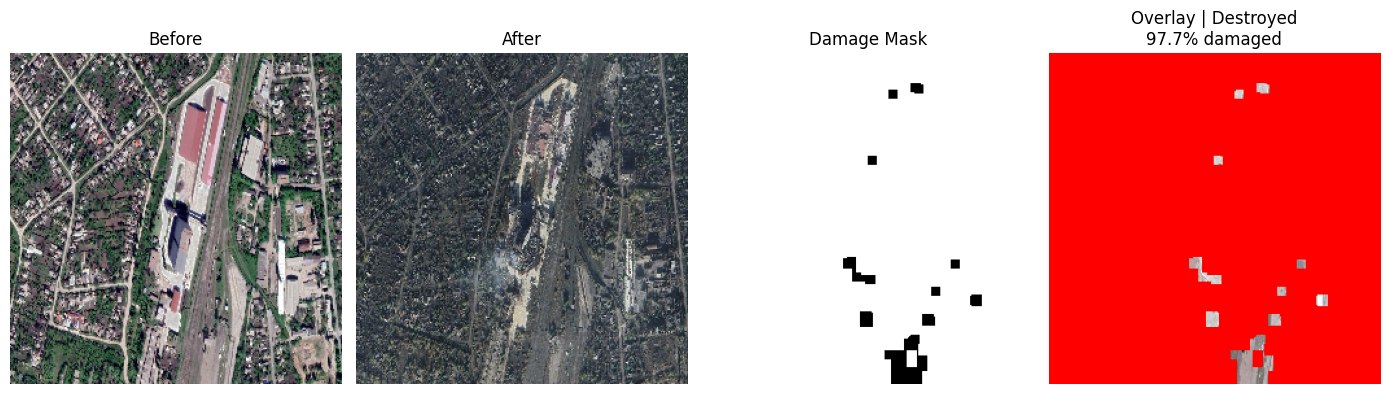

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load images
before = cv2.imread("/i3b.jpg")
after = cv2.imread("/i3a.jpg")

# ✅ FIX: Check if images are loaded successfully
if before is None:
    print("Error: Could not load image from /i3b.jpg. Please ensure the file exists.")
    # Optionally, handle the error more gracefully, e.g., create a black image or exit.
    # For now, we'll stop execution if a critical image isn't found.
    exit()
if after is None:
    print("Error: Could not load image from /i3a.jpg. Please ensure the file exists.")
    exit()

# Resize
before = cv2.resize(before, (256, 256))
after = cv2.resize(after, (256, 256))

# ✅ FIX 1: Equalize brightness before comparing
def normalize_image(img):
    img_yuv = cv2.cvtColor(img, cv2.COLOR_BGR2YUV)
    img_yuv[:,:,0] = cv2.equalizeHist(img_yuv[:,:,0])
    return cv2.cvtColor(img_yuv, cv2.COLOR_YUV2BGR)

before_norm = normalize_image(before)
after_norm = normalize_image(after)

# Convert to grayscale
before_gray = cv2.cvtColor(before_norm, cv2.COLOR_BGR2GRAY)
after_gray = cv2.cvtColor(after_norm, cv2.COLOR_BGR2GRAY)

# ✅ FIX 2: Use SSIM-style difference (more accurate)
diff = cv2.absdiff(before_gray, after_gray)

# ✅ FIX 3: Raise threshold (was 30, now 60)
_, thresh = cv2.threshold(diff, 60, 255, cv2.THRESH_BINARY)

# ✅ FIX 4: Bigger kernel to remove more noise
kernel = np.ones((7,7), np.uint8)
clean = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
clean = cv2.morphologyEx(clean, cv2.MORPH_OPEN, kernel)

# ✅ FIX 5: Overlay damage ON original image (looks better)
damage_overlay = before.copy()
damage_overlay[clean == 255] = [0, 0, 255]  # Red = damaged areas

# Calculate damage %
damage_pixels = np.sum(clean == 255)
total_pixels = clean.size
damage_ratio = damage_pixels / total_pixels

# Classify
if damage_ratio < 0.05:
    label = "No Damage"
elif damage_ratio < 0.15:
    label = "Minor Damage"
elif damage_ratio < 0.30:
    label = "Major Damage"
else:
    label = "Destroyed"

print(f"Damage: {damage_ratio*100:.2f}%")
print("Label:", label)

# ✅ FIX 6: Show 4 panels now
plt.figure(figsize=(14, 4))

plt.subplot(1,4,1)
plt.title("Before")
plt.imshow(cv2.cvtColor(before, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1,4,2)
plt.title("After")
plt.imshow(cv2.cvtColor(after, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1,4,3)
plt.title("Damage Mask")
plt.imshow(clean, cmap='gray')
plt.axis('off')

plt.subplot(1,4,4)
plt.title(f"Overlay | {label}\n{damage_ratio*100:.1f}% damaged")
plt.imshow(cv2.cvtColor(damage_overlay, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.tight_layout()
plt.show()

Damage: 100.00%
Label: Destroyed


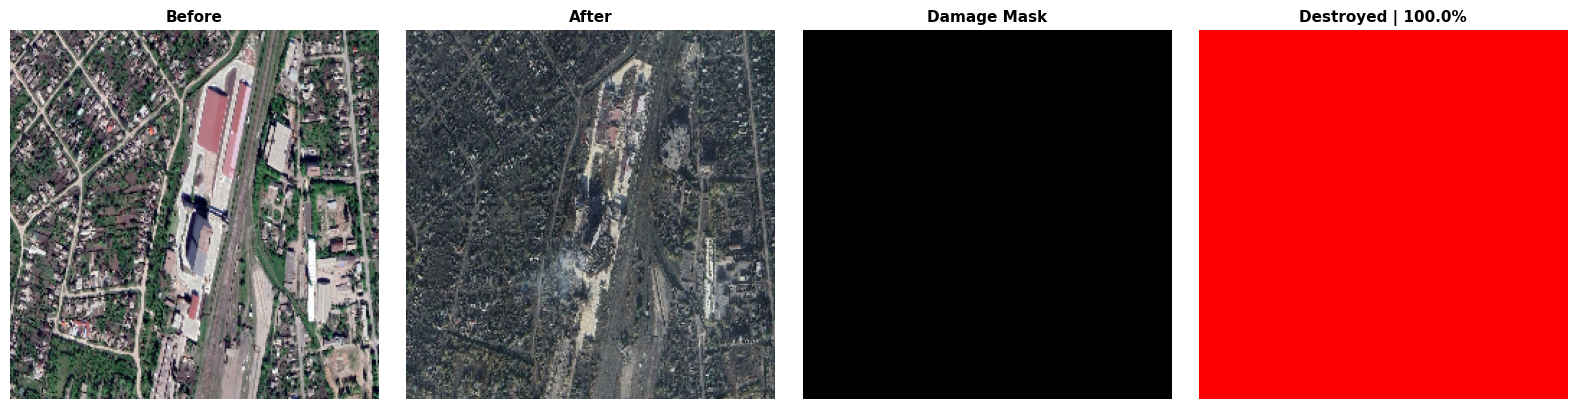

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

before = cv2.imread("/i3b.jpg")
after  = cv2.imread("/i3a.jpg")

before = cv2.resize(before, (256, 256))
after  = cv2.resize(after,  (256, 256))

# ✅ FIX: Use CLAHE (better than equalizeHist)
def apply_clahe(img):
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    lab[:,:,0] = clahe.apply(lab[:,:,0])
    return cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)

before_c = apply_clahe(before)
after_c  = apply_clahe(after)

before_gray = cv2.cvtColor(before_c, cv2.COLOR_BGR2GRAY)
after_gray  = cv2.cvtColor(after_c,  cv2.COLOR_BGR2GRAY)

# ✅ FIX: Compare EDGES not raw pixels
# Edges = structures (buildings, roads) — not affected by color/season
before_edges = cv2.Canny(before_gray, 50, 150)
after_edges  = cv2.Canny(after_gray,  50, 150)

# Difference in structural edges = real damage
edge_diff = cv2.absdiff(before_edges, after_edges)

# ✅ FIX: Also use raw pixel diff but normalize it
pixel_diff = cv2.absdiff(before_gray, after_gray)
pixel_diff = cv2.normalize(pixel_diff, None, 0, 255, cv2.NORM_MINMAX)

# ✅ FIX: Combine both signals (edges + pixel)
combined = cv2.addWeighted(edge_diff, 0.6, pixel_diff, 0.4, 0)

# ✅ FIX: Higher threshold + Otsu (auto-picks best threshold)
_, thresh = cv2.threshold(combined, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Clean noise
kernel = np.ones((5,5), np.uint8)
clean = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
clean = cv2.morphologyEx(clean, cv2.MORPH_OPEN, kernel)

# ✅ FIX: Only keep LARGE contours (ignore tiny noise spots)
contours, _ = cv2.findContours(clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
final_mask = np.zeros_like(clean)
for cnt in contours:
    if cv2.contourArea(cnt) > 150:  # ignore tiny blobs
        cv2.drawContours(final_mask, [cnt], -1, 255, -1)

# Overlay damaged areas in RED on After image
overlay = after.copy()
overlay[final_mask == 255] = [0, 0, 255]

# Calculate damage %
damage_ratio = np.sum(final_mask == 255) / final_mask.size

if damage_ratio < 0.05:
    label = "No Damage"
elif damage_ratio < 0.15:
    label = "Minor Damage"
elif damage_ratio < 0.30:
    label = "Major Damage"
else:
    label = "Destroyed"

print(f"Damage: {damage_ratio*100:.2f}%")
print("Label:", label)

# Plot
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
titles = ["Before", "After", "Damage Mask", f"{label} | {damage_ratio*100:.1f}%"]
images = [
    cv2.cvtColor(before, cv2.COLOR_BGR2RGB),
    cv2.cvtColor(after,  cv2.COLOR_BGR2RGB),
    final_mask,
    cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)
]
cmaps = [None, None, 'gray', None]

for ax, img, title, cmap in zip(axes, images, titles, cmaps):
    ax.imshow(img, cmap=cmap)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()